# EDA: Bank Marketing Dataset
## Bước 1: Thu thập & hiểu dữ liệu
**Nguồn dữ liệu:** UCI Machine Learning Repository - Bank Marketing Dataset
(https://archive.ics.uci.edu/dataset/222/bank+marketing)

**Bối cảnh:** Dữ liệu các chiến dịch telemarketing (gọi điện trực tiếp) của một ngân hàng Bồ Đào Nha, nhằm mời khách hàng đăng ký gửi tiết kiệm có kỳ hạn (term deposit). Mục tiêu bài toán: dự đoán khách hàng có đăng ký hay không (biến `y` / `subscribed`).
 
**Kích thước:** 41,188 X 21 cột

### Data Dictionary
## A. Nhóm thông tin khách hàng (Client info)

| Feature | Phân loại | Thang đo | Discrete/Continuous | Ý nghĩa |
|---------|-----------|----------|---------------------|----------|
| Age | Định lượng | Ordinal | Discrete | Tuổi khách hàng |
| Job | Định tính | Nominal | - | Nghề nghiệp |
| Marital | Định tính | Nominal | - | Tình trạng hôn nhân |
| Education | Định tính | Ordinal | - | Trình độ học vấn |
| Default | Định tính | Binary | - | Có nợ xấu không? |
| Housing | Định tính | Binary | - | Có khoản vay mua nhà không? |
| Loan | Định tính | Binary | - | Có khoản vay cá nhân không? |

---

## B. Nhóm thông tin liên hệ (Contact info)

| Feature | Phân loại | Thang đo | Discrete/Continuous | Ý nghĩa |
|---------|-----------|----------|---------------------|----------|
| Contact | Định tính | Nominal | - | Loại thiết bị liên lạc |
| Month | Định tính | Ordinal | - | Tháng gọi cuối cùng |
| Day_of_week | Định tính | Ordinal | - | Ngày trong tuần gọi cuối |
| Duration | Định lượng | - | Discrete | Thời lượng cuộc gọi (s) |

---

## C. Nhóm thông tin chiến dịch (Campaign info)

| Feature | Phân loại | Thang đo | Discrete/Continuous | Ý nghĩa |
|---------|-----------|----------|---------------------|----------|
| Campaign | Định lượng | - | Discrete | Số lần liên hệ |
| Pdays | Định lượng | - | Discrete | Số ngày từ chiến dịch |
| Previous | Định lượng | - | Discrete | Số lần liên hệ trước |
| Poutcome | Định tính | Nominal | - | Kết quả chiến dịch trước |

---

## D. Nhóm kinh tế vĩ mô (Social & Economic)

| Feature | Phân loại | Thang đo | Data Type | Ý nghĩa | Giá trị |
|---------|-----------|----------|-----------|----------|---------|
| emp.var.rate | Định lượng | Tỉ lệ (Ratio) | Continuous | Tỷ lệ biến động việc làm | `[-3.4; 1.1]` |
| cons.price.idx | Định lượng | Tỉ lệ (Ratio) | Continuous | Chỉ số giá tiêu dùng | `[92.2; 94.8]` |
| cons.conf.idx | Định lượng | Tỉ lệ (Ratio) | Continuous | Chỉ số niềm tin tiêu dùng | `[-50.8; -26.9]` |
| euribor3m | Định lượng | Tỉ lệ (Ratio) | Continuous | Lãi suất Euribor 3 tháng | `[0.6; 5.0]` |
| nr.employed | Định lượng | Tỉ lệ (Ratio) | Continuous | Số lượng nhân viên (nghìn người) | `[4963; 5228]` |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")

from preprocess import load_data

%matplotlib inline
sns.set_style("whitegrid")

In [3]:
bank_data = load_data("../data/raw/bank-additional-full.csv")

print("Kích thước dataset:", bank_data.shape)

bank_data.head()

bank_data.info()

bank_data.columns


Kích thước dataset: (41188, 21)
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

## Bước 2: EDA (Phân tích khám phá)
### Phần A - Thông tin khách hàng (bank_client)

In [4]:
bank_client = bank_data.iloc[:, 0:7]
bank_client.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


Min age:  17
Max age:  98
Null values:  False


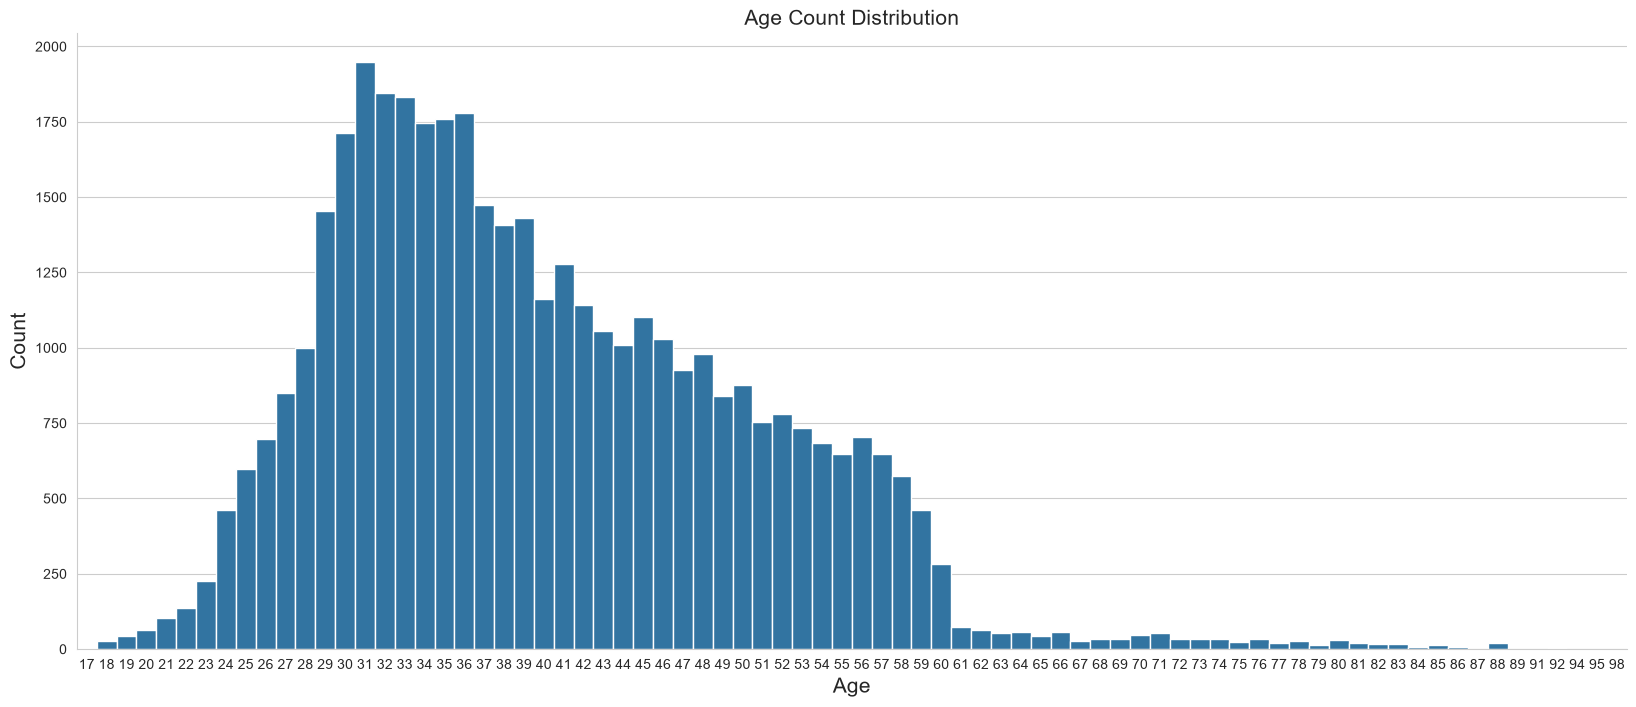

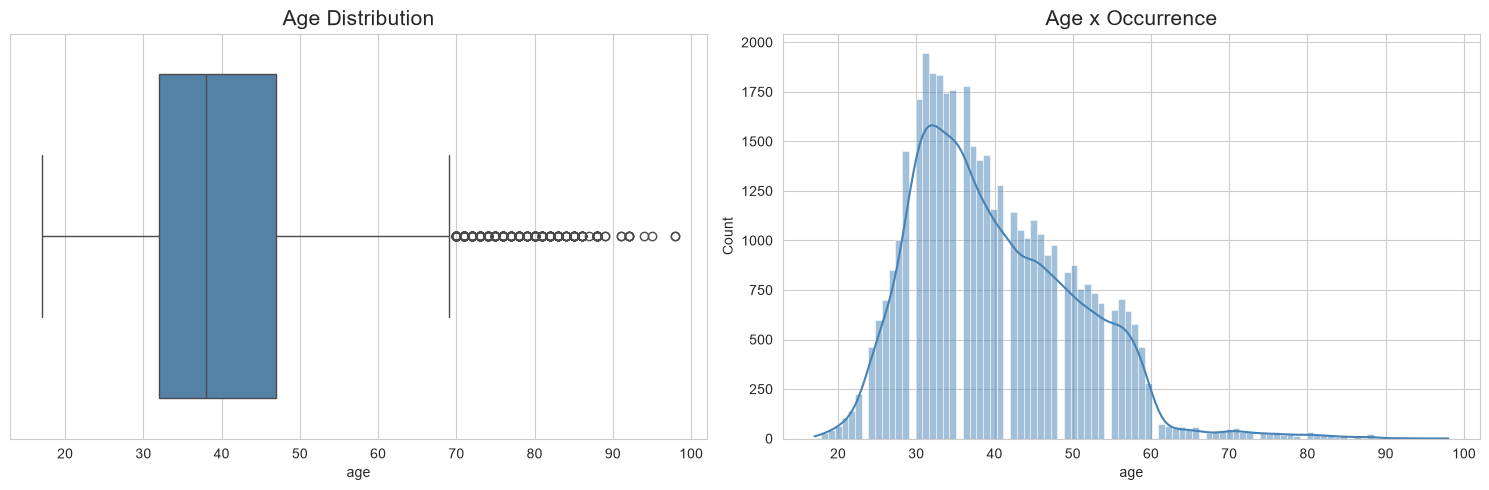

In [34]:
print('Min age: ', bank_client['age'].min())
print('Max age: ', bank_client['age'].max())
print('Null values: ', bank_client['age'].isnull().any())

### CountPlot
fig_a, ax_a = plt.subplots(figsize=(20, 8))
sns.countplot(x='age', data=bank_client, ax=ax_a, width=1.0)
ax_a.set_xlabel('Age', fontsize=15)
ax_a.set_ylabel('Count', fontsize=15)
ax_a.set_title('Age Count Distribution', fontsize=15)
sns.despine() # Loại bỏ đường viền trên và phải

fig_b, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

sns.boxplot(x='age', data=bank_client, color='steelblue', orient='v', ax=ax1)
ax1.set_title('Age Distribution', fontsize=15)

sns.histplot(bank_client['age'], color='steelblue', kde=True, ax=ax2)
ax2.set_title('Age x Occurrence', fontsize=15)

plt.tight_layout()

In [6]:
# Outline 
q1 = bank_client['age'].quantile(0.25)

q3 = bank_client['age'].quantile(0.75)
iqr = q3 - q1 # 8
upper_bound = q3 + 1.5 * iqr

print('Ages above', round(upper_bound, 1), 'are outliers')

n_outliers = bank_client[bank_client['age'] > upper_bound]['age'].count()

print('Number of outliers:', n_outliers)
print('Outliers are:', round(n_outliers * 100 / len(bank_client), 2),'%')

print('MEAN:', round(bank_client['age'].mean(), 1))
print('STD :', round(bank_client['age'].std(), 1))

Ages above 69.5 are outliers
Number of outliers: 469
Outliers are: 1.14 %
MEAN: 40.0
STD : 10.4


#### A.3-6 Jobs, Marital, Education, Default/Housing/Loan

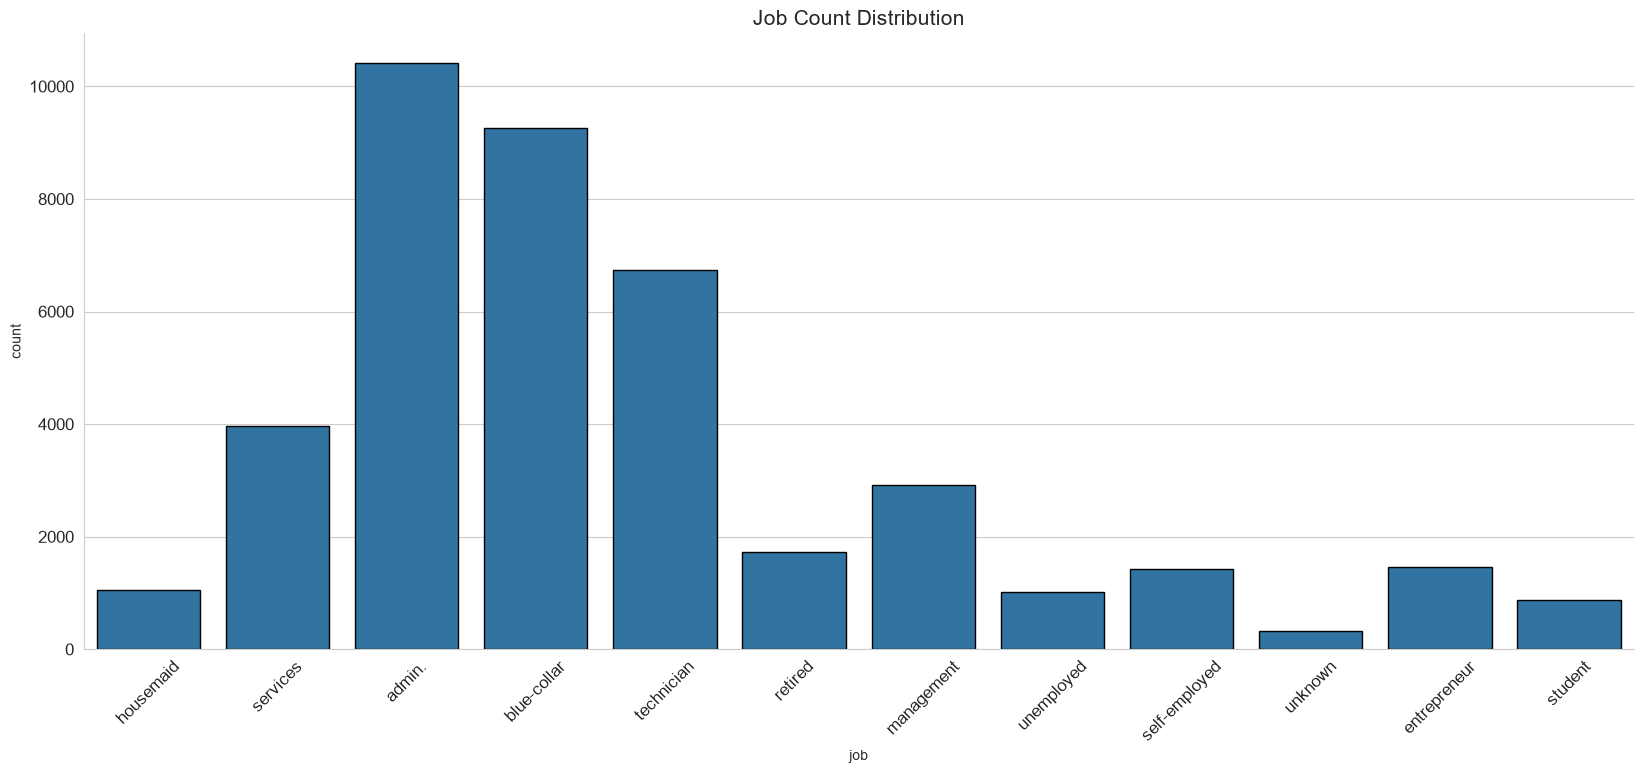

In [24]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.countplot(x='job', data=bank_client, ax=ax, edgecolor="k")
ax.set_title('Job Count Distribution', fontsize=15)
ax.tick_params(labelsize=12)
plt.xticks(rotation=45)
sns.despine()

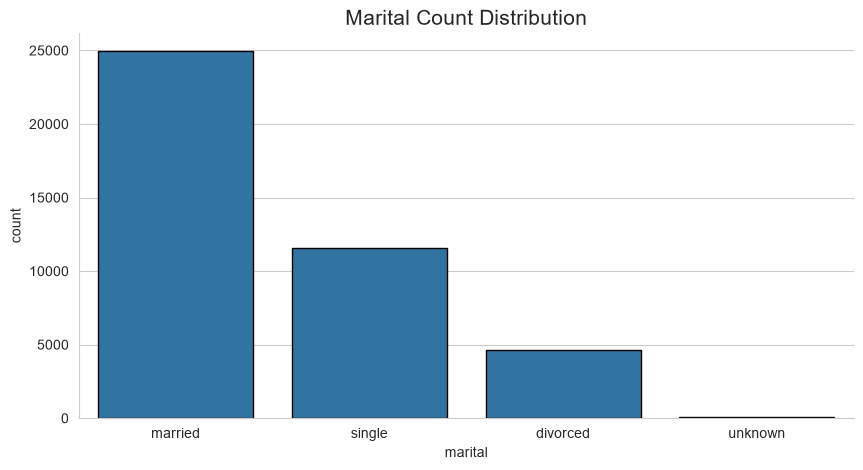

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x='marital', data=bank_client, ax=ax, edgecolor="k")
ax.set_title('Marital Count Distribution', fontsize=15)
sns.despine()

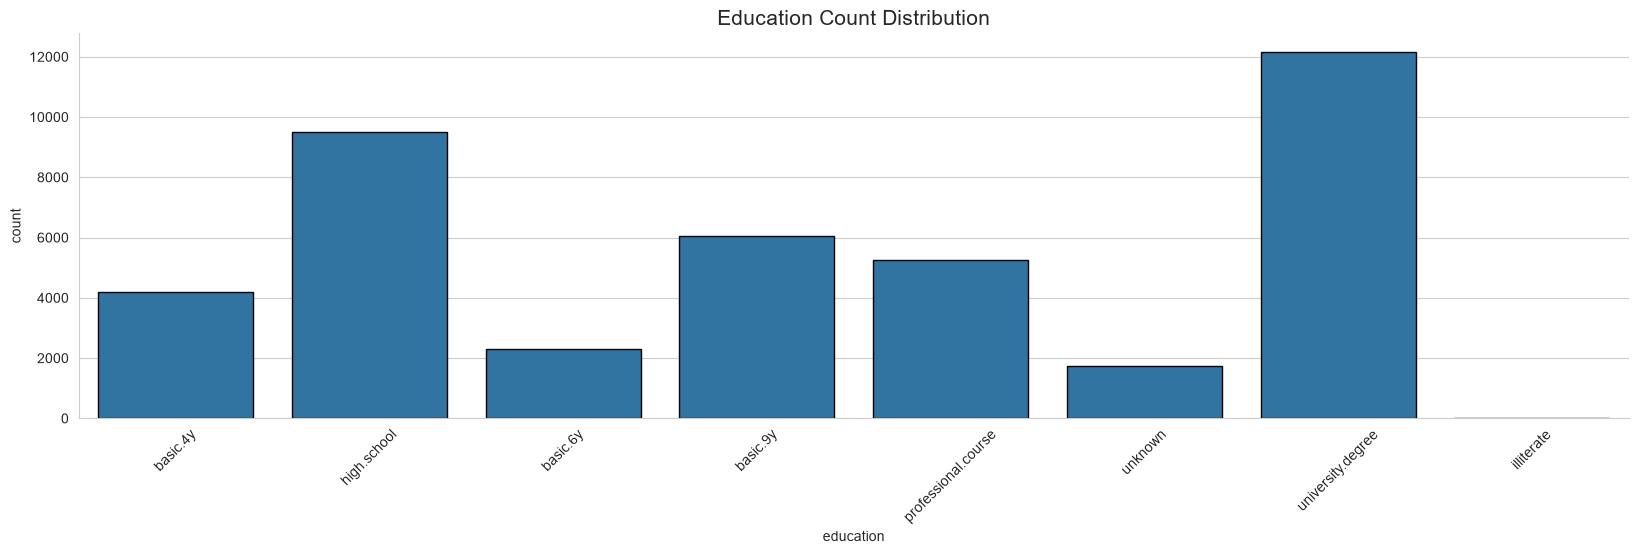

In [25]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.countplot(x='education', data=bank_client, ax=ax, edgecolor="k")
ax.set_title('Education Count Distribution', fontsize=15)
plt.xticks(rotation=45)
sns.despine()

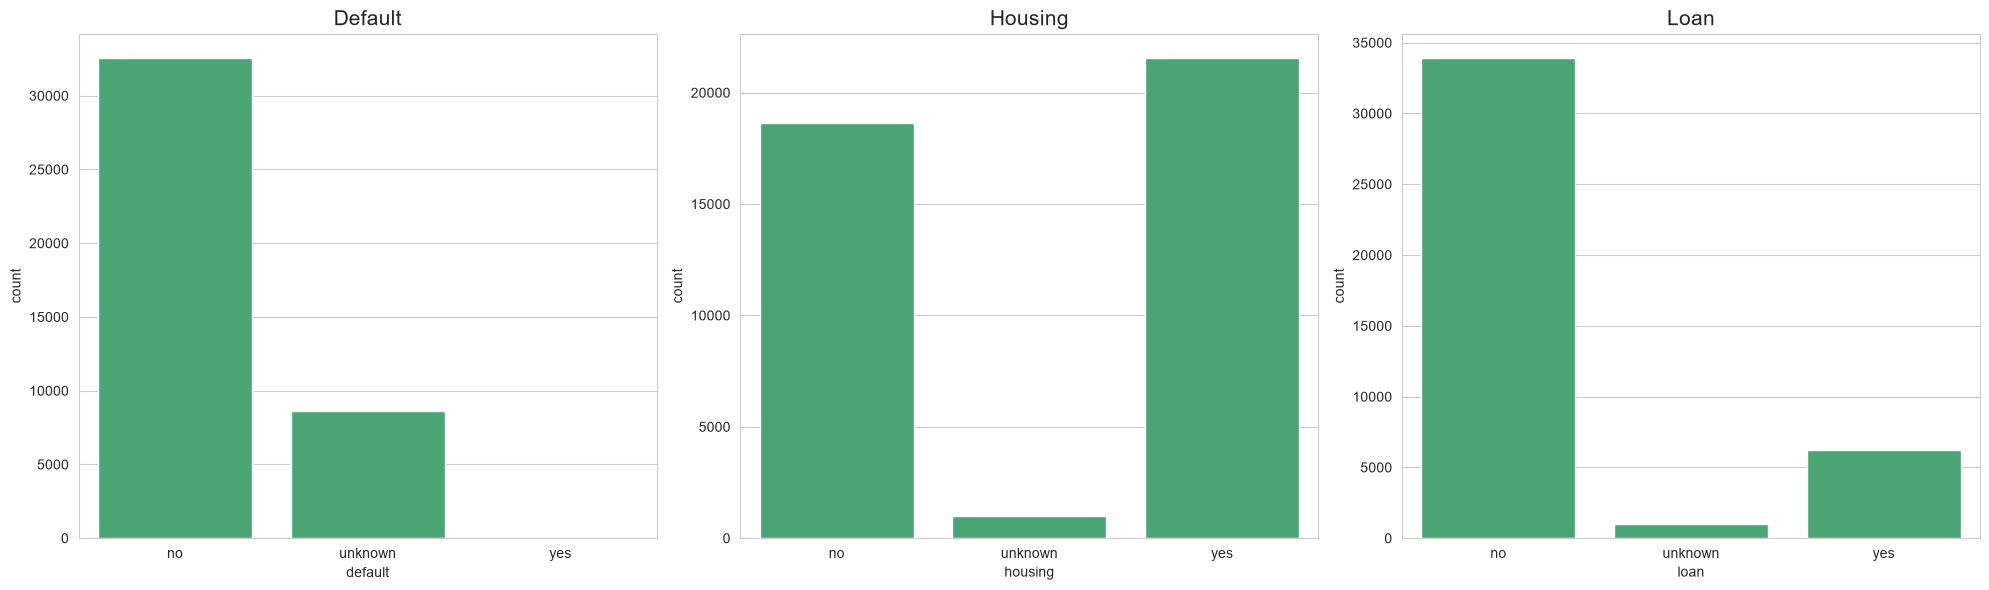

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.countplot(x='default', data=bank_client, color='mediumseagreen', ax=ax1, order=['no', 'unknown', 'yes'])
ax1.set_title('Default', fontsize=15)

sns.countplot(x='housing', data=bank_client, color='mediumseagreen', ax=ax2, order=['no', 'unknown', 'yes'])
ax2.set_title('Housing', fontsize=15)

sns.countplot(x='loan', data=bank_client, color='mediumseagreen', ax=ax3, order=['no', 'unknown', 'yes'])
ax3.set_title('Loan', fontsize=15)

plt.tight_layout()

**Nhận xét:**
Tuổi khách hàng tập trung chủ yếu 30-50, có uotlier ở nhóm tuổi cao (1.4%)
Nghề 'admin' và 'blue-collar' chiếm đa số
Đa phần khách hàng đã kết hôn.
Cột 'default' có tỉ lệ 'unknown' khá lớn - đây là lí do ta không xem 'unknown' như một 'missing value'

### Phần B - Thông tin liên hệ chiến dịch

In [37]:
bank_related = bank_data.iloc[:, 7:11]
bank_related.head()

,contact,month,day_of_week,duration
0,telephone,may,mon,261
1,telephone,may,mon,149
2,telephone,may,mon,226
3,telephone,may,mon,151
4,telephone,may,mon,307


In [38]:
print('Các hình thức liên hệ:', bank_related['contact'].unique().tolist())
print('Các tháng:', bank_related['month'].unique().tolist())
print('Các ngày trong tuần:', bank_related['day_of_week'].unique().tolist())

Các hình thức liên hệ: ['telephone', 'cellular']
Các tháng: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
Các ngày trong tuần: ['mon', 'tue', 'wed', 'thu', 'fri']


#### B.1 Duration

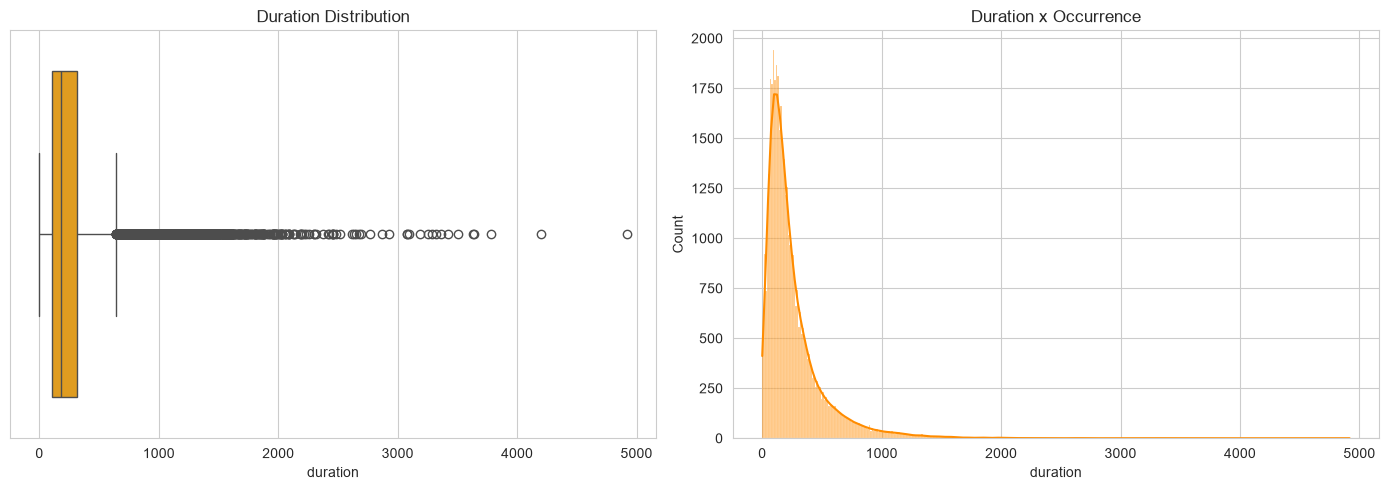

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='duration', data=bank_related, color='orange', orient='v', ax=ax1)
ax1.set_title('Duration Distribution', fontsize=12)

sns.histplot(bank_related['duration'], color='darkorange', kde=True, ax=ax2)
ax2.set_title('Duration x Occurrence', fontsize=12)

plt.tight_layout()

In [14]:
print('Max duration (min):', round(bank_related['duration'].max() / 60, 1))
print('Min duration (min):', round(bank_related['duration'].min() / 60, 1))
print('Mean duration (min):', round(bank_related['duration'].mean() / 60, 1))

q1_d = bank_related['duration'].quantile(0.25)
q3_d = bank_related['duration'].quantile(0.75)
upper_d = q3_d + 1.5 * (q3_d - q1_d)
print('Duration calls above', upper_d, 'are outliers')

n_zero = bank_related[bank_related['duration'] == 0].shape[0]
print(f'Số dòng duration=0 (sẽ bị loại ở bước clean vì gây leakage): {n_zero}')

Max duration (min): 82.0
Min duration (min): 0.0
Mean duration (min): 4.3
Duration calls above 644.5 are outliers
Số dòng duration=0 (sẽ bị loại ở bước clean vì gây leakage): 4


#### B.2 Contact, Month, Day of Week

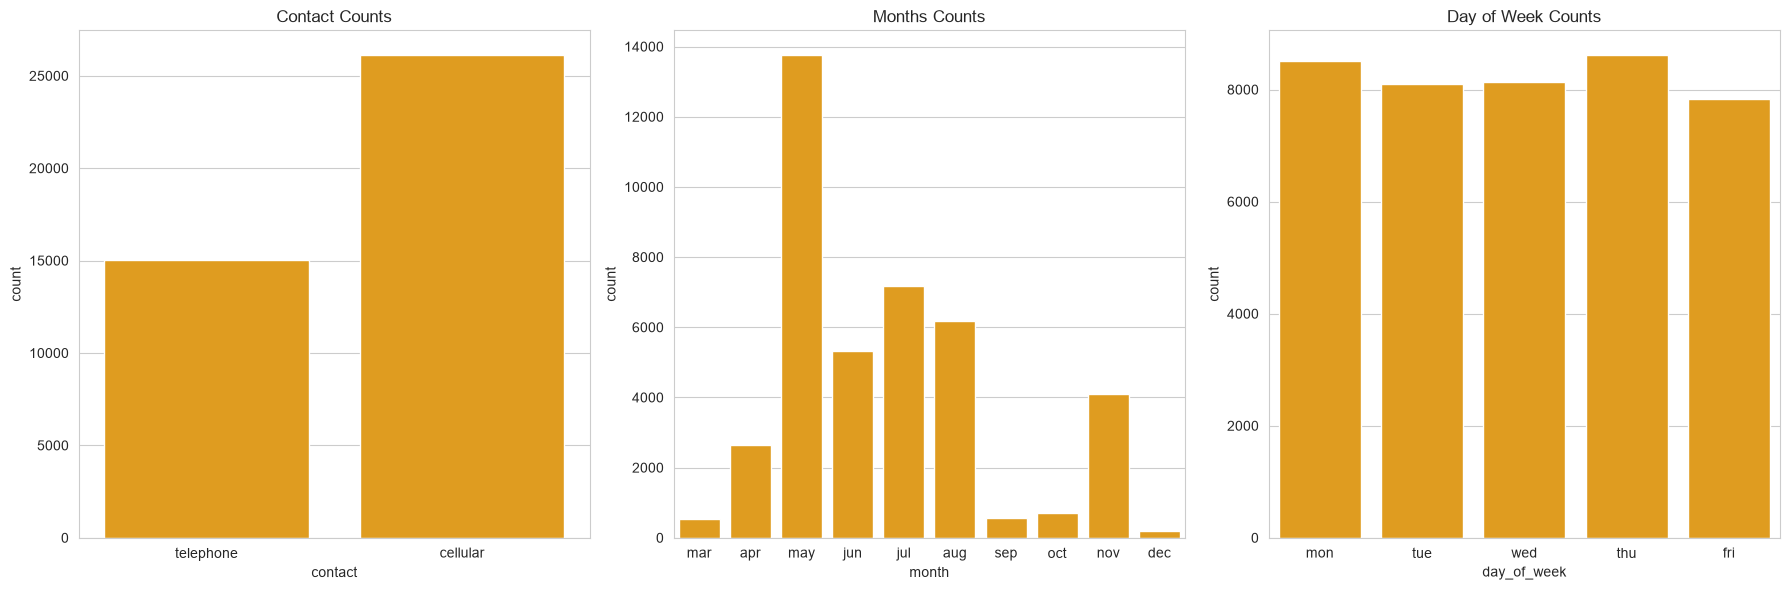

In [66]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.countplot(x='contact', data=bank_related, color='orange', ax=ax1)
ax1.set_title('Contact Counts')

sns.countplot(x='month', data=bank_related, color='orange', ax=ax2,
              order=['mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
ax2.set_title('Months Counts')

sns.countplot(x='day_of_week', data=bank_related, color='orange', ax=ax3)
ax3.set_title('Day of Week Counts')

plt.tight_layout()

**Nhận xét:** 

Tháng `may` có số cuộc gọi nhiều vượt trội. 

Duration có đuôi phải rất dài (một số cuộc gọi kéo dài bất thường) và có các dòng `duration=0`(cuộc gọi chưa xảy ra).

### Phần C - Mất cân bằng lớp (Class Imbalance) 

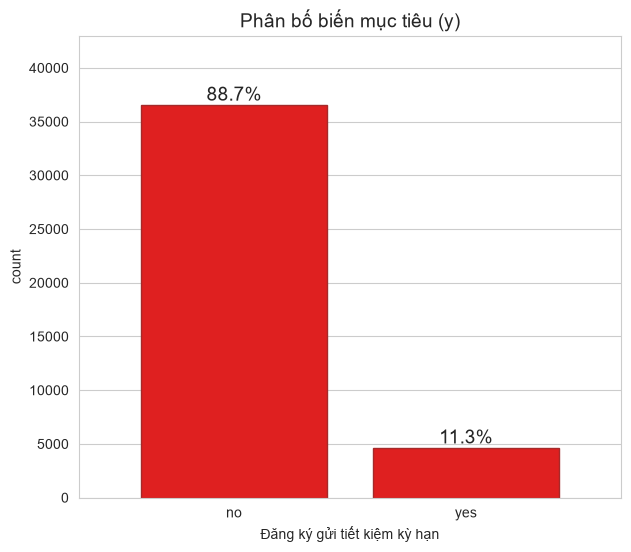

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [84]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.countplot(x='y', data=bank_data, color='red', ax=ax, edgecolor="brown" )
ax.set_title('Phân bố biến mục tiêu (y)', fontsize=14)
ax.set_xlabel('Đăng ký gửi tiết kiệm kỳ hạn')

ax.set_ylim(0, 43000)      # Trục y lên đến 40.000
ax.margins(x=0.15)

counts = bank_data['y'].value_counts()
pct = bank_data['y'].value_counts(normalize=True) * 100
for i, v in enumerate(counts):
    ax.text(i, v + 400, f'{pct.iloc[i]:.1f}%', ha='center', fontsize=14)

plt.show()

print(counts)
print(pct.round(2))

**Nhận xét:** Dataset bị **mất cân bằng lớp nghiêm trọng** 

Trong đó: 
nhóm `no` chiếm khoảng 88-89%, nhóm `yes` chỉ khoảng 11-12%. 

### Phần D - Tương quan giữa các biến số (Correlation)

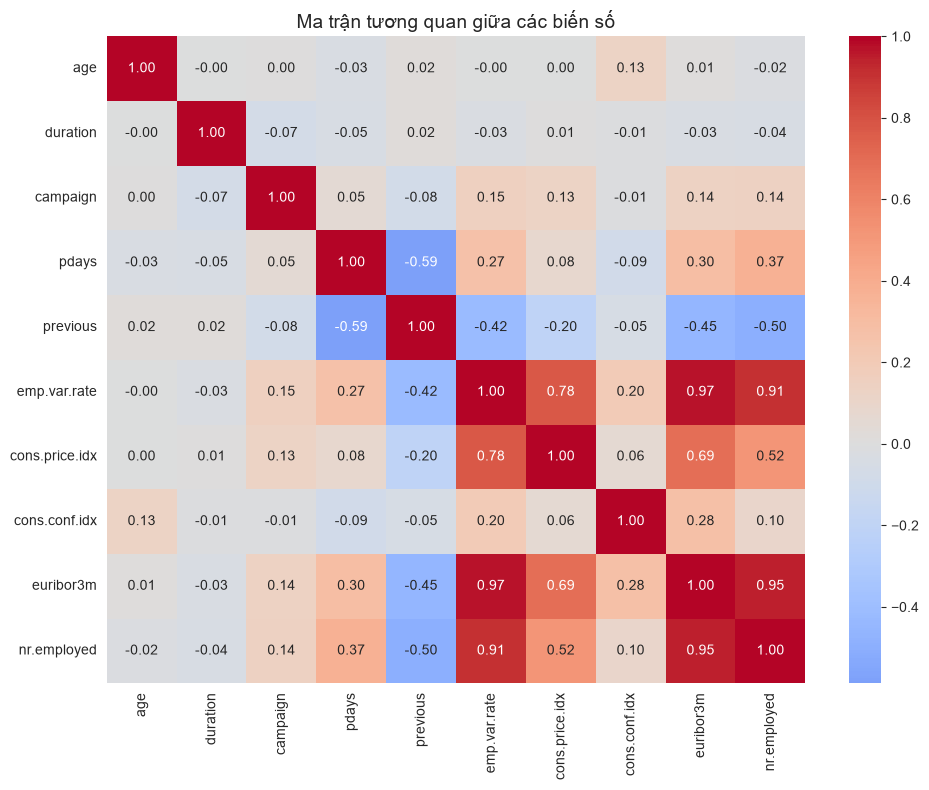

In [41]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']

corr_matrix = bank_data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Ma trận tương quan giữa các biến số', fontsize=14)
plt.tight_layout()
plt.show()

**Nhận xét:** 
Nhóm biến kinh tế vĩ mô tương quan rất mạnh với nhau (đa cộng tuyến) - cần lưu ý khi dùng các model tuyến tính như Logistic Regression. 
Ngoài ra, `pdays` và `previous` cũng có tương quan đáng chú ý (liên quan đến việc từng liên hệ trước đó hay chưa).

## Tổng kết 
- Dataset: 41,188 dòng, 21 cột, không có NaN thật nhưng có `'unknown'` ở nhiều cột phân loại.
- **Mất cân bằng lớp nghiêm trọng** (~89% no / ~11% yes) 
- **Rủi ro rò rỉ dữ liệu (data leakage)** với cột `duration`: cần xử lý ở bước
  tiền xử lý (loại `duration=0`, cân nhắc bỏ hẳn cột nếu bài toán là dự đoán
  *trước* cuộc gọi).
- Các biến kinh tế vĩ mô tương quan mạnh với nhau